# Flood prediction using Decision Tree Algorith

In [31]:
#import required data analytics libraries :
import pandas as pd, numpy as np, seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#importing models for decision tree classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
#tracing the file path
path ="C:\\Users\\ASUS\\Documents\\data_bank\\flood_prediction_dataset.xlsx"

In [4]:
#reading in the dataset
data = pd.read_excel(path)

In [5]:
#display the first 10 records
data.head(10)

,Date,Location,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
0,2023-01-01,CityB,35.9,19.2,52.1,9.44,29.8,0
1,2023-01-02,CityA,235.6,32.2,92.5,2.43,19.7,0
2,2023-01-03,CityA,1.8,29.7,71.2,8.49,32.0,0
3,2023-01-04,CityA,164.8,33.7,50.3,4.53,38.8,0
4,2023-01-05,CityA,50.8,28.5,71.7,4.82,37.9,0
5,2023-01-06,CityC,53.5,13.8,36.1,3.86,28.0,0
6,2023-01-07,CityA,152.4,32.6,77.6,5.36,21.7,0
7,2023-01-08,CityB,142.3,34.6,55.6,7.12,17.4,0
8,2023-01-09,CityB,80.9,17.4,79.6,3.32,40.4,0
9,2023-01-10,CityC,142.7,29.4,62.0,9.29,38.3,0


In [6]:
#inspect the data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               10000 non-null  datetime64[ns]
 1   Location           10000 non-null  object        
 2   Rainfall (mm)      10000 non-null  float64       
 3   Temperature (°C)   10000 non-null  float64       
 4   Humidity (%)       10000 non-null  float64       
 5   River Level (m)    10000 non-null  float64       
 6   Soil Moisture (%)  10000 non-null  float64       
 7   Flood Risk         10000 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 625.1+ KB


In [7]:
#Descriptive data analysis
data.describe()

,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000
mean,150.815320,22.73913,65.288330,5.502467,27.45563,0.113900
std,86.065119,7.26114,20.110403,2.591013,12.93138,0.317706
min,0.100000,10.00000,30.000000,1.000000,5.00000,0.000000
25%,77.100000,16.50000,48.075000,3.250000,16.50000,0.000000
50%,149.500000,22.80000,65.300000,5.460000,27.30000,0.000000
75%,225.100000,29.10000,82.600000,7.790000,38.60000,0.000000
max,300.000000,35.00000,100.000000,10.000000,50.00000,1.000000


In [8]:
#observe correlations
data.corr()

,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
Rainfall (mm),1.000000,-0.000234,0.008526,0.013670,0.003758,0.409345
Temperature (°C),-0.000234,1.000000,0.004030,0.000443,-0.002842,0.000942
Humidity (%),0.008526,0.004030,1.000000,-0.019404,0.010782,-0.015190
River Level (m),0.013670,0.000443,-0.019404,1.000000,0.003499,0.419775
Soil Moisture (%),0.003758,-0.002842,0.010782,0.003499,1.000000,0.006946
Flood Risk,0.409345,0.000942,-0.015190,0.419775,0.006946,1.000000


In [9]:
#check for the possibility of null values
data.isna().sum()

Date                 0
Location             0
Rainfall (mm)        0
Temperature (°C)     0
Humidity (%)         0
River Level (m)      0
Soil Moisture (%)    0
Flood Risk           0
dtype: int64

In [10]:
#inspect for anomaly in the target (goal), to be sure its fit for making predictions
data["Flood Risk"].unique()      #  codes: 0 - not flooded , 1 - flooded

array([0, 1], dtype=int64)

In [11]:
#check the number of dates involved in the analysis 
data["Date"].unique()

array(['2023-01-01T00:00:00.000000000', '2023-01-02T00:00:00.000000000',
       '2023-01-03T00:00:00.000000000', ...,
       '2050-05-16T00:00:00.000000000', '2050-05-17T00:00:00.000000000',
       '2050-05-18T00:00:00.000000000'], dtype='datetime64[ns]')

From the Exploratory Data Analysis we can deduce that the dataset is clean and can be used model building. 

# Model Building

In [12]:
#converting Location column from Qualitative to quantitative by creating dummy data
df1= pd.get_dummies(data["Location"])
df1

,CityA,CityB,CityC,CityD
0,0,1,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0
...,...,...,...,...
9995,0,0,0,1
9996,1,0,0,0
9997,1,0,0,0
9998,1,0,0,0


In [13]:
#combine dummy data with the main dataframe
data= pd.concat([df1,data], axis=1)
data

,CityA,CityB,CityC,CityD,Date,Location,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
0,0,1,0,0,2023-01-01,CityB,35.9,19.2,52.1,9.44,29.8,0
1,1,0,0,0,2023-01-02,CityA,235.6,32.2,92.5,2.43,19.7,0
2,1,0,0,0,2023-01-03,CityA,1.8,29.7,71.2,8.49,32.0,0
3,1,0,0,0,2023-01-04,CityA,164.8,33.7,50.3,4.53,38.8,0
4,1,0,0,0,2023-01-05,CityA,50.8,28.5,71.7,4.82,37.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,1,2050-05-14,CityD,273.9,30.8,72.6,2.10,36.9,0
9996,1,0,0,0,2050-05-15,CityA,84.9,10.4,73.7,1.55,33.1,0
9997,1,0,0,0,2050-05-16,CityA,214.2,30.1,78.6,5.90,8.0,0
9998,1,0,0,0,2050-05-17,CityA,197.2,31.5,95.7,3.68,38.7,0


At this point, we will drop the columns that will will be redundant or irrelivant in the predictive analysis:
Take note that the value of column CityA can stand in for the rest of the cities (since its coded in binary). However, we will drop the location column , also we will drop the Date column

In [14]:
#drop columns
data= data.drop(columns=["CityB", "CityC","CityD","Location","Date"])

CityA now have all the information of Location columns coded in binary

## Predictive Analysis

In [15]:
#set goal (target)
target = data.pop("Flood Risk")

target

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Flood Risk, Length: 10000, dtype: int64

In [16]:
#observe that the Target colum "Flood Risk" is out from the rest of the data, this becomes the features
data

,CityA,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%)
0,0,35.9,19.2,52.1,9.44,29.8
1,1,235.6,32.2,92.5,2.43,19.7
2,1,1.8,29.7,71.2,8.49,32.0
3,1,164.8,33.7,50.3,4.53,38.8
4,1,50.8,28.5,71.7,4.82,37.9
...,...,...,...,...,...,...
9995,0,273.9,30.8,72.6,2.10,36.9
9996,1,84.9,10.4,73.7,1.55,33.1
9997,1,214.2,30.1,78.6,5.90,8.0
9998,1,197.2,31.5,95.7,3.68,38.7


In [18]:
#define the rest of the features
features = data.values

features

array([[  0.  ,  35.9 ,  19.2 ,  52.1 ,   9.44,  29.8 ],
       [  1.  , 235.6 ,  32.2 ,  92.5 ,   2.43,  19.7 ],
       [  1.  ,   1.8 ,  29.7 ,  71.2 ,   8.49,  32.  ],
       ...,
       [  1.  , 214.2 ,  30.1 ,  78.6 ,   5.9 ,   8.  ],
       [  1.  , 197.2 ,  31.5 ,  95.7 ,   3.68,  38.7 ],
       [  0.  ,  53.9 ,  14.  ,  38.1 ,   2.11,  41.8 ]])

In [19]:
# Splitting the dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=44)

In [21]:
#inititialising the DesicionTreeClassifier
model = DecisionTreeClassifier(random_state=44)
model

DecisionTreeClassifier(random_state=44)

In [22]:
#train the model
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=44)

In [23]:
# Making predictions on the test set
y_predict = model.predict(x_test)

y_predict

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [24]:
#Model's Accuracy
accuracy = accuracy_score(y_test, y_predict)

accuracy

0.9996666666666667

In [25]:
#Classification report
print("Classification Report:\n", classification_report(y_test, y_predict))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2644
           1       1.00      1.00      1.00       356

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [26]:
#confusion Matrix
confusion_matr = confusion_matrix(y_test, y_predict)

confusion_matr

array([[2643,    1],
       [   0,  356]], dtype=int64)

Text(0.5, 1.0, 'Confusion Matrix for Flood Risk Classification')

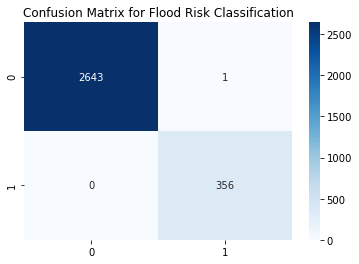

In [33]:
sns.heatmap(confusion_matr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Flood Risk Classification")

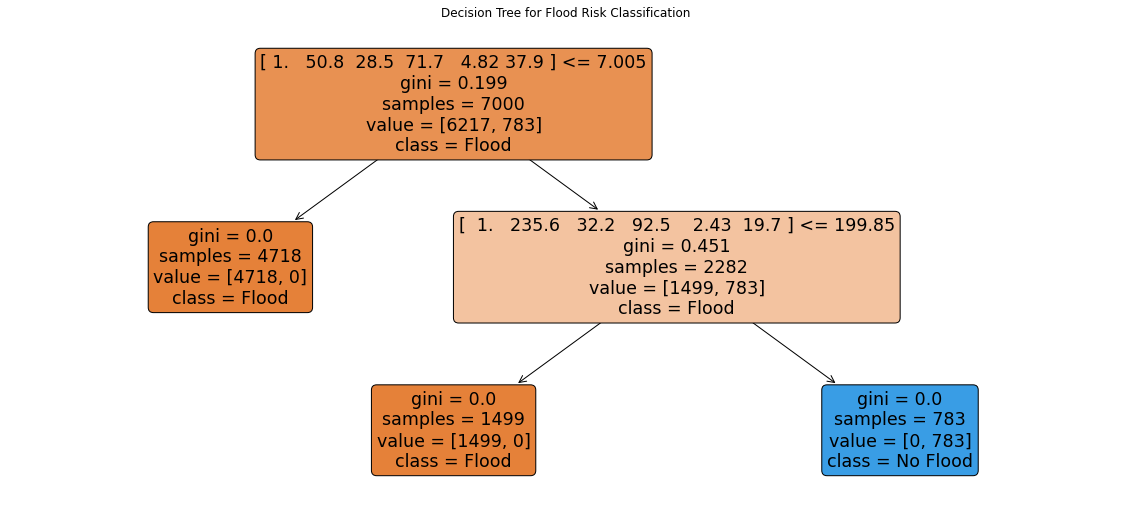

In [35]:
#plotting the decision tree
plt.figure(figsize=(20,9))
plot_tree(model, filled= True, feature_names= features, class_names=["Flood", "No Flood"], rounded= True )
plt.title("Decision Tree for Flood Risk Classification")
plt.show()